# Levo 4 / Levo 4 EVO — S4 geometry calculator

Specialized publishes **three** numbers per adjustment — chainstay length, BB height and head
tube angle (manual §11.1, `data/adjustable_geo_info.png`). But every one of these adjustments
re-levels the whole bike, so reach, stack, seat angle, wheelbase, front centre, trail and
effective top tube all move too. None of those are published. Fork length is not in that table
at all.

This notebook reconstructs the frame from the published charts, calibrates each adjustment
against the manual, and produces the **complete geometry sheet for all 36 legal configurations**
of an S4 Levo 4 and S4 Levo 4 EVO — including the columns Specialized leaves out — plus rear
suspension travel and the resulting sagged (riding) geometry.

| | Levo 4 | Levo 4 EVO |
|---|---|---|
| Fork | 160 / 170 mm | 170 / 180 mm |
| Horst pivot flip chip | Short / Long | Short / Long |
| Headset cup | −1° / 0° / +1° | −1° / 0° / +1° |
| Shock extension flip chip | Short / Long | — (Levo 4 only) |
| **Combinations** | **24** | **12** |

The EVO has no shock-extension flip chip: manual §11.3 is headed "LEVO 4 MODELS ONLY", and
§15.4.6 fits the EVO with a fixed mounting chip instead — "All Levo 4 EVO models are not designed
with the extension flip chip, as the shock extension does not have the necessary clearance with
the seat tube."

All calculations live in the stdlib-only `levo_geo` package next to this notebook, so they can be
run and tested without Jupyter.

In [1]:
import math
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "levo_geo").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from levo_geo import LEVO4, LEVO4_EVO, MODELS, build_rows, calibrate
from levo_geo.data import (
    HEADSET_CUP_DELTAS,
    HORST_LONG_DELTA,
    SHOCK_EXT_LONG_DELTA,
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

CALIBRATIONS = {model.short: calibrate(model) for model in MODELS}
print("levo_geo loaded from", ROOT)

levo_geo loaded from /home/pedro/dev_tmp/geo_calc


## 1. Source data

Two sources, both in `data/`:

* `levo4_geometry.csv` and `levo4_geometry_evo.csv` — the published geometry charts.
* `LEVO_G4_USER_MANUAL_ENGLISH.pdf` — the specifications table and §§11.1–11.3.

In [2]:
published = pd.DataFrame(
    {model.name: vars(model.geometry) for model in MODELS}
).rename_axis("S4 published geometry")
published

,Levo 4,Levo 4 EVO
S4 published geometry,,
reach,480.0,470.0
stack,638.0,646.0
head_tube_length,117.0,117.0
head_tube_angle,64.5,63.6
seat_tube_angle,77.0,76.0
chainstay,435.0,435.0
bb_height,350.0,356.0
bb_drop,29.5,24.0
wheelbase,1254.0,1263.0


In [3]:
specs = pd.DataFrame(
    {
        model.name: {
            "Stock fork travel (mm)": model.stock_fork_travel,
            "Min / max fork travel (mm)": "160 - 180",
            "Fork travel modelled (mm)": " / ".join(f"{t:g}" for t in model.fork_travel_options),
            "Rear wheel travel (mm)": model.rear_wheel_travel,
            "Shock length x stroke (mm)": f"{model.shock_length:g} x {model.shock_stroke:g}",
            "Average leverage ratio": round(model.leverage_ratio, 3),
            "Recommended shock sag (mm)": "{:g} - {:g}".format(*model.shock_sag_range),
            "Rear wheel sag (mm)": "{:.0f} - {:.0f}".format(*model.rear_wheel_sag_range),
            "Rear sag (% travel)": "{:.0f} - {:.0f}%".format(*model.rear_sag_percent_range),
            "Shock extension (mm)": model.shock_extension_length,
            "Shock extension flip chip": "yes" if model.has_shock_extension_chip else "no",
        }
        for model in MODELS
    }
).rename_axis("Manual specifications")
specs

,Levo 4,Levo 4 EVO
Manual specifications,,
Stock fork travel (mm),160.0,180.0
Min / max fork travel (mm),160 - 180,160 - 180
Fork travel modelled (mm),160 / 170,170 / 180
Rear wheel travel (mm),150.0,170.0
Shock length x stroke (mm),210 x 55,230 x 62.5
Average leverage ratio,2.727,2.72
Recommended shock sag (mm),14 - 16.5,17 - 18.5
Rear wheel sag (mm),38 - 45,46 - 50
Rear sag (% travel),25 - 30%,27 - 30%


The manual's "Adjustable Geometry Changes" table — the only per-adjustment data Specialized
publishes, and the target every adjustment below is calibrated against. It is identical for both
models.

In [4]:
pd.DataFrame(
    {
        "Horst pivot Long": HORST_LONG_DELTA,
        "Headset cup -1 deg": HEADSET_CUP_DELTAS[-1.0],
        "Headset cup +1 deg": HEADSET_CUP_DELTAS[+1.0],
        "Shock extension Long": SHOCK_EXT_LONG_DELTA,
    }
).rename_axis("Published delta from default")

,Horst pivot Long,Headset cup -1 deg,Headset cup +1 deg,Shock extension Long
Published delta from default,,,,
chainstay,11.0,0.0,0.0,-2.0
bb_height,-12.0,-2.0,2.0,6.0
head_tube_angle,-0.8,-1.0,1.0,0.4


## 2. The model

A 2-D rigid-body model in `levo_geo/frame.py`. Frame-local coordinates: bottom bracket at the
origin, +x forward, +y up, frame held at its stock attitude.

1. **Frame skeleton** — head tube top at `(reach, stack)`, head tube bottom one head-tube-length
   down the steer axis, seat tube through the BB, rear axle placed by the chainstay length.
2. **Fork** — `axle = ht_bottom + a2c · (cosα, −sinα) + rake · (sinα, cosα)`. Axle-to-crown tracks
   travel 1:1: the charts give 160 → 577 and 180 → 597, so `a2c = 417 + travel`.
3. **Re-level** — rotate the whole assembly until both axles sit at their wheel radii again, then
   read every dimension in ground reference. A nose-up rotation tips the head tube toward
   horizontal, so ground-referenced angles are the frame-local angle *minus* the pitch.

Each adjustment touches exactly one input: fork length sets `a2c`, the headset cup tilts the steer
axis within the frame, and the two flip chips move the rear axle within the frame. Front and rear
adjustments therefore never interfere, and **all** of the interaction between them falls out of the
re-levelling step rather than from adding the manual's deltas together.

### Does the reconstruction actually reproduce the published charts?

In [5]:
checks = []
for model in MODELS:
    cal = CALIBRATIONS[model.short]
    got, want = cal.stock, model.geometry
    for label, modelled, chart in [
        ("Head tube angle", got.head_tube_angle, want.head_tube_angle),
        ("Seat tube angle", got.seat_tube_angle, want.seat_tube_angle),
        ("BB height", got.bb_height, want.bb_height),
        ("Reach", got.reach, want.reach),
        ("Stack", got.stack, want.stack),
        ("Wheelbase", got.wheelbase, want.wheelbase),
        ("Front centre", got.front_center, want.front_center),
        ("Trail", got.trail, want.trail),
        ("Effective top tube", got.effective_top_tube, want.effective_top_tube),
    ]:
        checks.append(
            {
                "Model": model.name,
                "Dimension": label,
                "Reconstructed": round(modelled, 2),
                "Published": chart,
                "Residual": round(modelled - chart, 2),
            }
        )

reconstruction = pd.DataFrame(checks).pivot(
    index="Dimension", columns="Model", values=["Reconstructed", "Published", "Residual"]
)
print("Largest residual anywhere: {:.2f}".format(pd.DataFrame(checks)["Residual"].abs().max()))
reconstruction

Largest residual anywhere: 1.08


Reconstructed            Published            Residual           
Model                     Levo 4 Levo 4 EVO    Levo 4 Levo 4 EVO   Levo 4 Levo 4 EVO
Dimension                                                                           
BB height                 349.64     355.30     350.0      356.0    -0.36      -0.70
Effective top tube        627.17     630.81     627.0      630.0     0.17       0.81
Front centre              819.06     827.29     820.0      828.0    -0.94      -0.71
Head tube angle            64.55      63.69      64.5       63.6     0.05       0.09
Reach                     480.53     471.04     480.0      470.0     0.53       1.04
Seat tube angle            77.05      76.09      77.0       76.0     0.05       0.09
Stack                     637.60     645.24     638.0      646.0    -0.40      -0.76
Trail                     131.89     138.79     132.0      139.0    -0.11      -0.21
Wheelbase                1253.51    1261.92    1254.0     1263.0    -0.49      -1.08

Every dimension lands within ~1 mm / 0.1° of the published chart — and wheelbase, front centre,
trail and top tube were never inputs to the reconstruction. Three of those deserve calling out:

* **Trail** falls out at 131.9 and 138.8 against published 132 and 139, from nothing but the head
  angle, rake and wheel radius. Getting it right also pins the front wheel radius at ≈380 mm and
  confirms that **BB drop on these mullet bikes is measured to the front axle**, not to the
  mid-point of the two — referenced any other way the trail figures do not reproduce.
* **Effective top tube** matches to <1 mm only if the seat tube passes through the bottom bracket.
  So it does, and effective seat angle is therefore constant with saddle height.
* And an independent cross-check below.

### Cross-check: the EVO chart is the Levo 4 frame, rotated

If the model is right, the two published charts are not independent — same frame, different link
and fork, so the EVO chart should be the Levo 4 chart pitched nose-up by the difference in head
angle (0.9°) and nothing else. Nothing below is fitted; it is one rotation applied to Levo 4
numbers and compared against the EVO chart.

In [6]:
from levo_geo.frame import rotate

g4, ge = LEVO4.geometry, LEVO4_EVO.geometry
pitch = g4.head_tube_angle - ge.head_tube_angle
reach_r, stack_r = rotate((g4.reach, g4.stack), pitch)
sta_r = g4.seat_tube_angle - pitch
ett_r = reach_r + stack_r / math.tan(math.radians(sta_r))

pd.DataFrame(
    {
        "Levo 4 chart": [g4.reach, g4.stack, g4.seat_tube_angle, g4.effective_top_tube],
        f"rotated {pitch:+.2f} deg": [
            round(reach_r, 1), round(stack_r, 1), round(sta_r, 2), round(ett_r, 1)
        ],
        "EVO chart": [ge.reach, ge.stack, ge.seat_tube_angle, ge.effective_top_tube],
    },
    index=["Reach", "Stack", "Seat tube angle", "Effective top tube"],
)

,Levo 4 chart,rotated +0.90 deg,EVO chart
Reach,480.0,469.9,470.0
Stack,638.0,645.5,646.0
Seat tube angle,77.0,76.1,76.0
Effective top tube,627.0,629.7,630.0


Reach 469.9 against a published 470, stack 645.5 against 646. The two charts really are one frame
at two attitudes, which is exactly what the model assumes.

## 3. Calibration

### Flip chips

Each flip chip is fitted as a rigid relocation of the rear axle within the frame — two free
parameters, `(dx, dy)`, against **three** published targets. Being over-determined by one, the
residual is a genuine test rather than a curve fit: if the manual's chainstay/BB/head-angle triple
were not the consequence of a single rigid relocation, it would not close.

In [7]:
fits = []
for model in MODELS:
    cal = CALIBRATIONS[model.short]
    for group in (cal.horst, cal.shock_ext):
        fit = group.get("Long")
        if fit is None:
            continue
        fits.append(
            {
                "Model": model.name,
                "Chip": fit.name,
                "dx (mm)": round(fit.dx, 3),
                "dy (mm)": round(fit.dy, 3),
                "CS residual": round(fit.residual["chainstay"], 3),
                "BB residual": round(fit.residual["bb_height"], 3),
                "HTA residual": round(fit.residual["head_tube_angle"], 3),
            }
        )
pd.DataFrame(fits).set_index(["Model", "Chip"])

dx (mm)  dy (mm)  CS residual  BB residual  HTA residual
Model      Chip                                                                    
Levo 4     Horst Long      -10.627   18.236         -0.0        0.189        -0.027
           Shock Ext Long    2.094   -9.028         -0.0       -0.094         0.013
Levo 4 EVO Horst Long      -10.627   18.224         -0.0        0.148        -0.021

Sub-0.2 mm and sub-0.03° on all three targets. And the Horst chip, fitted **independently** from
each model's own chart, lands on the same offset both times — which it must, because the two bikes
share a rear triangle.

### Headset cups

The cup has one free parameter, so it cannot hit both published targets at once, and the manual is
ambiguous about which one it means. Tilting the steer axis by a literal 1° and re-levelling gives a
*net* head angle change of only ±0.77° (with BB ±1.8 mm, close to the published ±2 mm); reaching
the headline ±1.0° needs a physically ≈1.3° cup.

**This calculator anchors to the head angle**, so the ±1.0° in the geometry column is exact and
ground-referenced, matching how the Horst and shock-extension chips are treated. BB height is then
a prediction rather than a fit, landing 0.2–0.45 mm off the manual's rounded ±2 mm.

In [8]:
cups = []
for model in MODELS:
    for nominal, fit in sorted(CALIBRATIONS[model.short].cups.items()):
        if nominal == 0:
            continue
        cups.append(
            {
                "Model": model.name,
                "Cup": f"{nominal:+.0f} deg",
                "Physical tilt (deg)": round(fit.tilt, 3),
                "Net HTA change (deg)": nominal,
                "Predicted BB change (mm)": round(
                    HEADSET_CUP_DELTAS[nominal]["bb_height"] + fit.residual["bb_height"], 2
                ),
                "Manual BB change (mm)": HEADSET_CUP_DELTAS[nominal]["bb_height"],
            }
        )
pd.DataFrame(cups).set_index(["Model", "Cup"])

Physical tilt (deg)  Net HTA change (deg)  Predicted BB change (mm)  Manual BB change (mm)
Model      Cup                                                                                               
Levo 4     -1 deg               -1.302                  -1.0                     -2.29                   -2.0
           +1 deg                1.294                   1.0                      2.23                    2.0
Levo 4 EVO -1 deg               -1.322                  -1.0                     -2.44                   -2.0
           +1 deg                1.313                   1.0                      2.38                    2.0

## 4. Full results — all 36 configurations

Reported as `published baseline + modelled delta`, so the stock row is identical to the catalogue
chart and every other row differs from it by a physically derived amount. That keeps the
sub-millimetre rounding slop in the published (and over-determined) chart from leaking into all 36
rows.

Columns marked † are **not published by Specialized for any adjustment**.

In [9]:
CONFIG_COLUMNS = {
    "fork_travel": "Fork",
    "horst_pivot": "Horst",
    "headset_cup": "Cup",
    "shock_extension": "Shock ext",
}
GEOMETRY_COLUMNS = {
    "head_tube_angle": "HTA",
    "seat_tube_angle": "STA †",
    "bb_height": "BB height",
    "bb_drop": "BB drop †",
    "reach": "Reach †",
    "stack": "Stack †",
    "chainstay": "CS",
    "wheelbase": "WB †",
    "front_center": "FC †",
    "trail": "Trail †",
    "mechanical_trail": "Mech trail †",
    "wheel_flop": "Flop †",
    "effective_top_tube": "ETT †",
    "standover": "Standover †*",
}
ANGLE_COLUMNS = {"HTA", "STA †"}


def table(rows, deltas=False):
    """Configuration rows as a display DataFrame, optionally as deltas from stock."""
    frame = pd.DataFrame(rows)
    stock = frame[frame["is_stock"]].iloc[0]
    out = frame[list(CONFIG_COLUMNS)].rename(columns=CONFIG_COLUMNS)
    out["Fork"] = out["Fork"].map("{:.0f}".format)
    for key, label in GEOMETRY_COLUMNS.items():
        values = frame[key] - (stock[key] if deltas else 0)
        out[label] = values.round(2 if label in ANGLE_COLUMNS else 1)
    out.insert(0, "", ["stock" if s else "" for s in frame["is_stock"]])
    return out.set_index(["", *CONFIG_COLUMNS.values()])


STATIC = {model.short: build_rows(model, CALIBRATIONS[model.short]) for model in MODELS}
print("Levo 4: {} configurations   Levo 4 EVO: {} configurations".format(
    len(STATIC["levo4"]), len(STATIC["levo4_evo"])
))

Levo 4: 24 configurations   Levo 4 EVO: 12 configurations


### Levo 4 — all 24 configurations (mm and degrees)

In [10]:
table(STATIC["levo4"])

HTA  STA †  BB height  BB drop †  Reach †  Stack †     CS    WB †   FC †  Trail †  Mech trail †  Flop †  ETT †  Standover †*
      Fork Horst Cup    Shock ext                                                                                                                                
      160  Short -1 deg Short      63.50  77.30      347.7       31.8    483.4    635.5  435.0  1265.5  831.6    139.8         125.1    55.8  626.2         751.2
                        Long       63.91  77.71      353.6       25.9    487.9    632.0  433.0  1263.7  831.6    136.6         122.7    53.9  625.3         757.8
stock 160  Short 0 deg  Short      64.50  77.00      350.0       29.5    480.0    638.0  435.0  1254.0  820.0    132.0         119.1    51.3  627.0         753.0
      160  Short 0 deg  Long       64.91  77.41      355.9       23.6    484.6    634.5  433.0  1252.2  820.0    128.8         116.7    49.5  626.0         759.6
                 +1 deg Short      65.50  76.71      352.2       27.3    476.7    640.5  435.0  1242.5  808.4    124.3         113.1    46.9  627.7         754.7
                        Long       65.92  77.12      358.1       21.4    481.4    637.0  433.0  1240.6  808.4    121.2         110.6    45.1  626.7         761.3
           Long  -1 deg Short      62.68  76.48      335.8       43.7    474.2    642.3  446.0  1275.7  831.6    146.3         129.9    59.6  628.3         737.9
                        Long       63.08  76.89      341.7       37.8    478.7    639.0  443.6  1273.8  831.6    143.1         127.6    57.7  627.3         744.5
                 0 deg  Short      63.67  76.17      338.2       41.3    470.7    644.9  446.0  1264.3  820.0    138.4         124.1    55.0  629.2         739.8
                        Long       64.08  76.58      344.0       35.5    475.3    641.5  443.6  1262.3  820.0    135.2         121.6    53.2  628.1         746.3
                 +1 deg Short      64.67  75.87      340.5       39.0    467.4    647.3  446.0  1252.9  808.4    130.7         118.1    50.5  630.0         741.6
                        Long       65.08  76.29      346.3       33.2    472.0    643.9  443.6  1250.8  808.4    127.5         115.7    48.7  628.9         748.1
      170  Short -1 deg Short      63.10  76.90      350.8       28.7    478.9    638.9  435.0  1269.8  835.7    143.0         127.5    57.7  627.3         753.6
                        Long       63.50  77.31      356.7       22.8    483.4    635.4  433.0  1267.9  835.7    139.7         125.1    55.8  626.2         760.2
                 0 deg  Short      64.09  76.59      353.1       26.4    475.4    641.4  435.0  1258.1  824.0    135.2         121.6    53.1  628.1         755.4
                        Long       64.50  77.00      359.0       20.5    480.0    638.0  433.0  1256.2  824.0    132.0         119.1    51.3  627.0         762.0
                 +1 deg Short      65.08  76.29      355.4       24.1    472.0    643.9  435.0  1246.4  812.3    127.5         115.7    48.7  628.8         757.2
                        Long       65.50  76.70      361.3       18.2    476.7    640.5  433.0  1244.5  812.3    124.4         113.2    46.9  627.8         763.8
           Long  -1 deg Short      62.28  76.08      338.9       40.6    469.7    645.6  446.0  1280.1  835.7    149.4         132.3    61.5  629.4         740.4
                        Long       62.68  76.49      344.8       34.7    474.3    642.3  443.6  1278.1  835.7    146.2         129.9    59.6  628.3         746.9
                 0 deg  Short      63.27  75.77      341.3       38.2    466.2    648.2  446.0  1268.6  824.0    141.6         126.5    56.9  630.3         742.3
                        Long       63.67  76.17      347.2       32.3    470.8    644.9  443.6  1266.5  824.0    138.4         124.1    55.0  629.2         748.8
                 +1 deg Short      64.26  75.46      343.7       35.8    462.7    650.7  446.0  1257.0  812.3    133.9         120.6    52.4  631.1  

### Levo 4 EVO — all 12 configurations (mm and degrees)

In [11]:
table(STATIC["levo4_evo"])

HTA  STA †  BB height  BB drop †  Reach †  Stack †     CS    WB †   FC †  Trail †  Mech trail †  Flop †  ETT †  Standover †*
      Fork Horst Cup    Shock ext                                                                                                                                
      170  Short -1 deg n/a        63.00  76.72      350.5       29.5    478.1    640.0  435.0  1270.6  835.8    143.7         128.0    58.1  628.1         758.8
                 0 deg  n/a        64.01  76.41      352.9       27.1    474.6    642.6  435.0  1258.8  823.9    135.8         122.1    53.5  628.9         760.6
                 +1 deg n/a        65.02  76.10      355.2       24.8    471.2    645.2  435.0  1246.9  812.0    128.0         116.1    49.0  629.7         762.4
           Long  -1 deg n/a        62.18  75.90      338.5       41.5    468.9    646.8  446.0  1280.7  835.8    150.3         132.9    62.0  630.3         745.4
                 0 deg  n/a        63.18  75.58      341.0       39.0    465.3    649.4  446.0  1269.0  823.9    142.3         127.0    57.3  631.2         747.3
                 +1 deg n/a        64.18  75.27      343.4       36.6    461.7    652.0  446.0  1257.3  812.0    134.5         121.0    52.7  632.0         749.1
      180  Short -1 deg n/a        62.60  76.32      353.6       26.4    473.6    643.3  435.0  1275.0  840.0    146.9         130.4    60.0  629.1         761.1
stock 180  Short 0 deg  n/a        63.60  76.00      356.0       24.0    470.0    646.0  435.0  1263.0  828.0    139.0         124.5    55.4  630.0         763.0
      180  Short +1 deg n/a        64.60  75.69      358.4       21.6    466.5    648.6  435.0  1251.0  815.9    131.2         118.5    50.8  630.9         764.8
           Long  -1 deg n/a        61.78  75.51      341.6       38.4    464.4    650.0  446.0  1285.3  840.0    153.4         135.2    63.9  631.4         747.7
                 0 deg  n/a        62.78  75.18      344.1       35.9    460.7    652.7  446.0  1273.4  828.0    145.5         129.4    59.2  632.3         749.7
                 +1 deg n/a        63.77  74.86      346.6       33.4    457.1    655.2  446.0  1261.5  815.9    137.6         123.5    54.6  633.2         751.5

### Rear suspension

Rear wheel travel is a property of the shock and link, not of the flip chips, so it is constant
across every configuration of a given model. It is carried on every exported row for completeness,
along with the shock and the sag figures used in §6.

In [12]:
rear = pd.DataFrame(
    [
        {
            "Model": model.name,
            "Rear wheel travel (mm)": model.rear_wheel_travel,
            "Shock (mm)": f"{model.shock_length:g} x {model.shock_stroke:g}",
            "Average leverage ratio": round(model.leverage_ratio, 3),
            "Shock sag (mm)": "{:g} - {:g}".format(*model.shock_sag_range),
            "Rear wheel sag (mm)": "{:.0f} - {:.0f}".format(*model.rear_wheel_sag_range),
            "Rear sag (% of travel)": "{:.0f} - {:.0f}%".format(*model.rear_sag_percent_range),
            "Configurations": len(STATIC[model.short]),
        }
        for model in MODELS
    ]
).set_index("Model")
rear

,Rear wheel travel (mm),Shock (mm),Average leverage ratio,Shock sag (mm),Rear wheel sag (mm),Rear sag (% of travel),Configurations
Model,,,,,,,
Levo 4,150.0,210 x 55,2.727,14 - 16.5,38 - 45,25 - 30%,24
Levo 4 EVO,170.0,230 x 62.5,2.720,17 - 18.5,46 - 50,27 - 30%,12


## 5. What the manual does not tell you

Each adjustment applied on its own to the stock bike. The first three columns are what Specialized
publishes; everything after is what actually also changes.

In [13]:
CONFIG_KEYS = ("fork_travel", "horst_pivot", "headset_cup", "shock_extension")


def isolated(model, **overrides):
    """The row for the stock bike with exactly one adjustment changed, and the stock row."""
    rows = STATIC[model.short]
    stock = next(r for r in rows if r["is_stock"])
    wanted = {**{k: stock[k] for k in CONFIG_KEYS}, **overrides}
    return next(r for r in rows if all(r[k] == v for k, v in wanted.items())), stock


def isolated_deltas(model):
    """Each adjustment's effect on its own, as a delta from stock."""
    # The stock fork is the short option on the Levo 4 and the long one on the EVO,
    # so "the other fork" is whichever of the two is not stock.
    other_fork = next(
        t for t in model.fork_travel_options if t != model.stock_fork_travel
    )
    cases = [
        (f"Fork {model.stock_fork_travel:g} -> {other_fork:g} mm", {"fork_travel": other_fork}),
        ("Horst pivot Long", {"horst_pivot": "Long"}),
        ("Headset cup -1 deg", {"headset_cup": "-1 deg"}),
        ("Headset cup +1 deg", {"headset_cup": "+1 deg"}),
    ]
    if model.has_shock_extension_chip:
        cases.append(("Shock extension Long", {"shock_extension": "Long"}))

    out = []
    for label, overrides in cases:
        row, stock = isolated(model, **overrides)
        entry = {"Adjustment": label}
        for key, column in GEOMETRY_COLUMNS.items():
            entry[column] = round(row[key] - stock[key], 2 if column in ANGLE_COLUMNS else 1)
        out.append(entry)
    return pd.DataFrame(out).set_index("Adjustment")


ISOLATED = {model.short: isolated_deltas(model) for model in MODELS}
ISOLATED["levo4"]

,HTA,STA †,BB height,BB drop †,Reach †,Stack †,CS,WB †,FC †,Trail †,Mech trail †,Flop †,ETT †,Standover †*
Adjustment,,,,,,,,,,,,,,
Fork 160 -> 170 mm,-0.41,-0.41,3.1,-3.1,-4.6,3.4,0.0,4.1,4.0,3.2,2.5,1.8,1.1,2.4
Horst pivot Long,-0.83,-0.83,-11.8,11.8,-9.3,6.9,11.0,10.3,-0.0,6.4,4.9,3.7,2.2,-13.2
Headset cup -1 deg,-1.00,0.30,-2.3,2.3,3.4,-2.5,0.0,11.5,11.6,7.8,6.0,4.5,-0.8,-1.8
Headset cup +1 deg,1.00,-0.29,2.2,-2.2,-3.3,2.5,0.0,-11.5,-11.6,-7.7,-6.0,-4.4,0.7,1.7
Shock extension Long,0.41,0.41,5.9,-5.9,4.6,-3.5,-2.0,-1.8,-0.0,-3.2,-2.5,-1.8,-1.0,6.6


In [14]:
ISOLATED["levo4_evo"]

,HTA,STA †,BB height,BB drop †,Reach †,Stack †,CS,WB †,FC †,Trail †,Mech trail †,Flop †,ETT †,Standover †*
Adjustment,,,,,,,,,,,,,,
Fork 180 -> 170 mm,0.41,0.41,-3.1,3.1,4.6,-3.4,0.0,-4.2,-4.1,-3.2,-2.4,-1.9,-1.1,-2.4
Horst pivot Long,-0.82,-0.82,-11.9,11.9,-9.3,6.7,11.0,10.4,0.0,6.5,4.9,3.8,2.3,-13.3
Headset cup -1 deg,-1.00,0.32,-2.4,2.4,3.6,-2.7,0.0,12.0,12.0,7.9,5.9,4.7,-0.9,-1.9
Headset cup +1 deg,1.00,-0.31,2.4,-2.4,-3.5,2.6,0.0,-12.0,-12.1,-7.8,-6.0,-4.5,0.9,1.8


The headline results, all of them unpublished:

* **The Horst pivot chip is a reach adjustment.** Going Long costs **9.3 mm of reach** and adds
  6.9 mm of stack — more than a stem size — and slackens the seat angle by 0.83°. The manual
  describes it purely as a chainstay/BB adjustment.
* **The headset cups move reach the *opposite* way to intuition.** The −1° cup slackens the head
  angle *and* lengthens frame reach by 3.4 mm, because the bike pitches nose-down as the front end
  drops. It also steepens the seat angle 0.3° and adds ~8 mm of trail.
* **A 10 mm fork change is not in the manual's table at all**, yet it moves reach ~4.6 mm, the head
  and seat angles ~0.41°, BB height ~3.1 mm and trail ~3.2 mm.
* Every single adjustment moves the **seat tube angle**, which the manual never mentions.

### Extremes

The full span each model can be configured across.

In [15]:
spans = []
for model in MODELS:
    frame = pd.DataFrame(STATIC[model.short])
    for key, column in GEOMETRY_COLUMNS.items():
        digits = 2 if column in ANGLE_COLUMNS else 1
        spans.append(
            {
                "Model": model.name,
                "Dimension": column,
                "Min": round(frame[key].min(), digits),
                "Stock": round(frame[frame["is_stock"]].iloc[0][key], digits),
                "Max": round(frame[key].max(), digits),
                "Span": round(frame[key].max() - frame[key].min(), digits),
            }
        )
pd.DataFrame(spans).set_index(["Model", "Dimension"])

Min   Stock      Max   Span
Model      Dimension                                    
Levo 4     HTA             62.28    64.5    65.92   3.64
           STA †           75.46    77.0    77.71   2.25
           BB height      335.80   350.0   361.30  25.50
           BB drop †       18.20    29.5    43.70  25.50
           Reach †        462.70   480.0   487.90  25.20
           Stack †        632.00   638.0   650.70  18.70
           CS             433.00   435.0   446.00  13.00
           WB †          1240.60  1254.0  1280.10  39.60
           FC †           808.40   820.0   835.70  27.40
           Trail †        121.20   132.0   149.40  28.30
           Mech trail †   110.60   119.1   132.30  21.70
           Flop †          45.10    51.3    61.50  16.40
           ETT †          625.30   627.0   631.10   5.90
           Standover †*   737.90   753.0   763.80  25.80
Levo 4 EVO HTA             61.78    63.6    65.02   3.23
           STA †           74.86    76.0    76.72   1.86
           BB height      338.50   356.0   358.40  19.80
           BB drop †       21.60    24.0    41.50  19.80
           Reach †        457.10   470.0   478.10  21.00
           Stack †        640.00   646.0   655.20  15.20
           CS             435.00   435.0   446.00  11.00
           WB †          1246.90  1263.0  1285.30  38.30
           FC †           812.00   828.0   840.00  28.10
           Trail †        128.00   139.0   153.40  25.40
           Mech trail †   116.10   124.5   135.20  19.10
           Flop †          49.00    55.4    63.90  14.90
           ETT †          628.10   630.0   633.20   5.20
           Standover †*   745.40   763.0   764.80  19.50

## 6. Sagged (riding) geometry

The tables above are static, unweighted numbers — the same convention as the catalogue chart, and
not the geometry anyone actually rides. Here the fork is compressed by 15% of its travel and the
rear axle is pushed into its travel by the midpoint of the manual's recommended sag, then the bike
is re-levelled with the same solver.

Specialized publishes the rear sag as shock-shaft millimetres (Levo 4 14–16.5 mm, EVO 17–18.5 mm);
those are converted to rear-wheel travel through the average leverage ratio. There is no published
fork sag figure, so 15% is the usual long-travel starting point — change `FORK_SAG` below to taste.

In [16]:
FORK_SAG = 0.15  # fraction of fork travel

SAGGED = {
    model.short: build_rows(
        model, CALIBRATIONS[model.short], sagged=True, fork_sag_fraction=FORK_SAG
    )
    for model in MODELS
}

sag_summary = []
for model in MODELS:
    static_stock = next(r for r in STATIC[model.short] if r["is_stock"])
    sag_stock = next(r for r in SAGGED[model.short] if r["is_stock"])
    entry = {
        "Model": model.name,
        "Fork sag (mm)": round(sag_stock["fork_sag_applied"], 1),
        "Rear wheel sag (mm)": round(sag_stock["rear_sag_applied"], 1),
    }
    for key, column in GEOMETRY_COLUMNS.items():
        if column in ("Standover †*", "Flop †", "Mech trail †", "BB drop †", "ETT †"):
            continue
        digits = 2 if column in ANGLE_COLUMNS else 1
        entry[column] = "{} -> {}".format(
            round(static_stock[key], digits), round(sag_stock[key], digits)
        )
    sag_summary.append(entry)

print("Stock configuration, static -> at recommended sag")
pd.DataFrame(sag_summary).set_index("Model").T

Stock configuration, static -> at recommended sag


Model,Levo 4,Levo 4 EVO
Fork sag (mm),24.0,27.0
Rear wheel sag (mm),41.6,48.3
HTA,64.5 -> 63.58,63.6 -> 62.5
STA †,77.0 -> 76.08,76.0 -> 74.9
BB height,350.0 -> 315.4,356.0 -> 316.1
Reach †,480.0 -> 469.7,470.0 -> 457.5
Stack †,638.0 -> 645.6,646.0 -> 655.0
CS,435.0 -> 437.0,435.0 -> 437.7
WB †,1254.0 -> 1243.3,1263.0 -> 1250.7
FC †,820.0 -> 810.8,828.0 -> 817.1


Sitting on the bike is a far bigger geometry change than any flip chip: it costs ~0.9° of head
angle, **35 mm of BB height** and 10 mm of reach on the Levo 4 (1.1° / 40 mm / 12.5 mm on the
longer-travel EVO). The Horst chip's headline 12 mm of BB height is a third of what the rider's own
weight takes out, and the catalogue's 350 mm BB is a number the bike essentially never sits at.

### Levo 4 — all 24 configurations at sag

In [17]:
table(SAGGED["levo4"])

HTA  STA †  BB height  BB drop †  Reach †  Stack †     CS    WB †   FC †  Trail †  Mech trail †  Flop †  ETT †  Standover †*
      Fork Horst Cup    Shock ext                                                                                                                                
      160  Short -1 deg Short      62.58  76.38      313.1       66.4    473.1    643.1  437.0  1254.3  822.0    147.0         130.5    60.1  628.6         715.1
                        Long       62.99  76.80      319.0       60.5    477.7    639.7  434.1  1252.3  822.0    143.8         128.1    58.2  627.5         721.6
stock 160  Short 0 deg  Short      63.58  76.08      315.4       64.1    469.7    645.6  437.0  1243.3  810.8    139.1         124.6    55.4  629.4         716.8
      160  Short 0 deg  Long       64.00  76.50      321.2       58.3    474.4    642.2  434.1  1241.4  810.8    135.9         122.1    53.5  628.3         723.4
                 +1 deg Short      64.58  75.79      317.6       61.9    466.4    648.0  437.0  1232.4  799.5    131.4         118.7    50.9  630.2         718.6
                        Long       65.00  76.21      323.4       56.1    471.1    644.6  434.1  1230.4  799.5    128.2         116.1    49.1  629.1         725.1
           Long  -1 deg Short      61.76  75.56      301.4       78.1    463.8    649.9  449.6  1264.8  822.0    153.6         135.3    64.0  630.8         701.9
                        Long       62.17  75.97      307.2       72.3    468.5    646.5  446.4  1262.7  822.0    150.3         132.9    62.1  629.7         708.4
                 0 deg  Short      62.76  75.26      303.8       75.7    460.4    652.3  449.6  1253.9  810.8    145.6         129.5    59.3  631.7         703.7
                        Long       63.17  75.67      309.5       70.0    465.0    649.0  446.4  1251.8  810.8    142.4         127.1    57.4  630.5         710.3
                 +1 deg Short      63.75  74.96      306.1       73.4    457.0    654.7  449.6  1243.1  799.5    137.8         123.6    54.7  632.6         705.5
                        Long       64.16  75.37      311.8       67.7    461.7    651.4  446.4  1240.9  799.5    134.6         121.1    52.8  631.4         712.0
      170  Short -1 deg Short      62.24  76.04      315.7       63.8    469.2    646.0  437.0  1258.0  825.4    149.8         132.5    61.7  629.5         717.1
                        Long       62.65  76.45      321.6       57.9    473.9    642.6  434.1  1256.0  825.4    146.5         130.1    59.8  628.4         723.7
                 0 deg  Short      63.23  75.73      318.0       61.5    465.8    648.5  437.0  1247.0  814.0    141.9         126.7    57.1  630.4         718.9
                        Long       63.65  76.15      323.9       55.6    470.4    645.1  434.1  1244.9  814.0    138.6         124.2    55.1  629.2         725.5
                 +1 deg Short      64.23  75.43      320.3       59.2    462.4    650.9  437.0  1235.9  802.6    134.1         120.8    52.5  631.2         720.6
                        Long       64.64  75.85      326.1       53.4    467.1    647.5  434.1  1233.8  802.6    130.9         118.3    50.7  630.0         727.2
           Long  -1 deg Short      61.42  75.22      304.0       75.5    460.0    652.6  449.6  1268.6  825.4    156.3         137.3    65.7  631.8         703.9
                        Long       61.83  75.63      309.8       69.7    464.6    649.3  446.4  1266.5  825.4    153.1         134.9    63.7  630.7         710.5
                 0 deg  Short      62.41  74.91      306.4       73.1    456.4    655.1  449.6  1257.7  814.0    148.4         131.5    60.9  632.7         705.8
                        Long       62.82  75.32      312.2       67.3    461.1    651.8  446.4  1255.5  814.0    145.1         129.1    59.0  631.5         712.3
                 +1 deg Short      63.40  74.61      308.8       70.7    453.0    657.5  449.6  1246.7  802.6    140.6         125.7    56.3  633.6  

### Levo 4 EVO — all 12 configurations at sag

In [18]:
table(SAGGED["levo4_evo"])

HTA  STA †  BB height  BB drop †  Reach †  Stack †     CS    WB †   FC †  Trail †  Mech trail †  Flop †  ETT †  Standover †*
      Fork Horst Cup    Shock ext                                                                                                                                
      170  Short -1 deg n/a        61.84  75.56      311.1       68.9    465.0    649.6  437.7  1258.1  825.4    153.0         134.9    63.7  631.2         717.3
                 0 deg  n/a        62.84  75.24      313.5       66.5    461.4    652.2  437.7  1247.0  813.9    145.0         129.0    58.9  632.1         719.1
                 +1 deg n/a        63.85  74.94      315.8       64.2    457.9    654.6  437.7  1235.8  802.3    137.1         123.0    54.2  633.0         720.9
           Long  -1 deg n/a        61.02  74.74      299.3       80.7    455.7    656.2  450.6  1268.6  825.4    159.7         139.7    67.7  633.6         704.0
                 0 deg  n/a        62.02  74.42      301.8       78.2    452.0    658.8  450.6  1257.6  813.9    151.5         133.8    62.8  634.6         705.9
                 +1 deg n/a        63.02  74.11      304.2       75.8    448.4    661.2  450.6  1246.5  802.3    143.6         127.9    58.0  635.6         707.7
      180  Short -1 deg n/a        61.50  75.22      313.7       66.3    461.2    652.4  437.7  1262.0  828.8    155.7         136.9    65.3  632.2         719.2
stock 180  Short 0 deg  n/a        62.50  74.90      316.1       63.9    457.5    655.0  437.7  1250.7  817.1    147.7         131.0    60.5  633.1         721.1
      180  Short +1 deg n/a        63.50  74.58      318.5       61.5    453.9    657.5  437.7  1239.4  805.4    139.8         125.1    55.8  634.1         722.9
           Long  -1 deg n/a        60.68  74.40      301.9       78.1    451.8    658.9  450.6  1272.6  828.8    162.4         141.6    69.3  634.6         706.0
                 0 deg  n/a        61.68  74.08      304.5       75.5    448.1    661.4  450.6  1261.5  817.1    154.3         135.8    64.4  635.6         707.9
                 +1 deg n/a        62.67  73.76      307.0       73.0    444.4    663.9  450.6  1250.2  805.4    146.3         130.0    59.7  636.7         709.7

## 7. Charts

In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Validated categorical palette, light mode, assigned in fixed slot order.
SERIES = {"Levo 4": "#2a78d6", "Levo 4 EVO": "#eb6834"}
# Diverging pair for signed change: blue (up) <-> red (down), neutral gray midpoint.
POSITIVE, NEGATIVE, NEUTRAL = "#2a78d6", "#e34948", "#f0efec"
INK, INK_SOFT = "#0b0b0b", "#52514e"
SURFACE = "#fcfcfb"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#d8d7d2",
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "medium",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#eceae5",
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "legend.fontsize": 9,
        "figure.dpi": 120,
    }
)

### The configuration space

Every configuration placed by head angle and BB height — the two axes riders actually shop on.
Colour carries the model, marker shape the fork length (so identity is never colour-alone), and
the stock setups are ringed and labelled.

findfont: Failed to find font weight medium, now using 400.


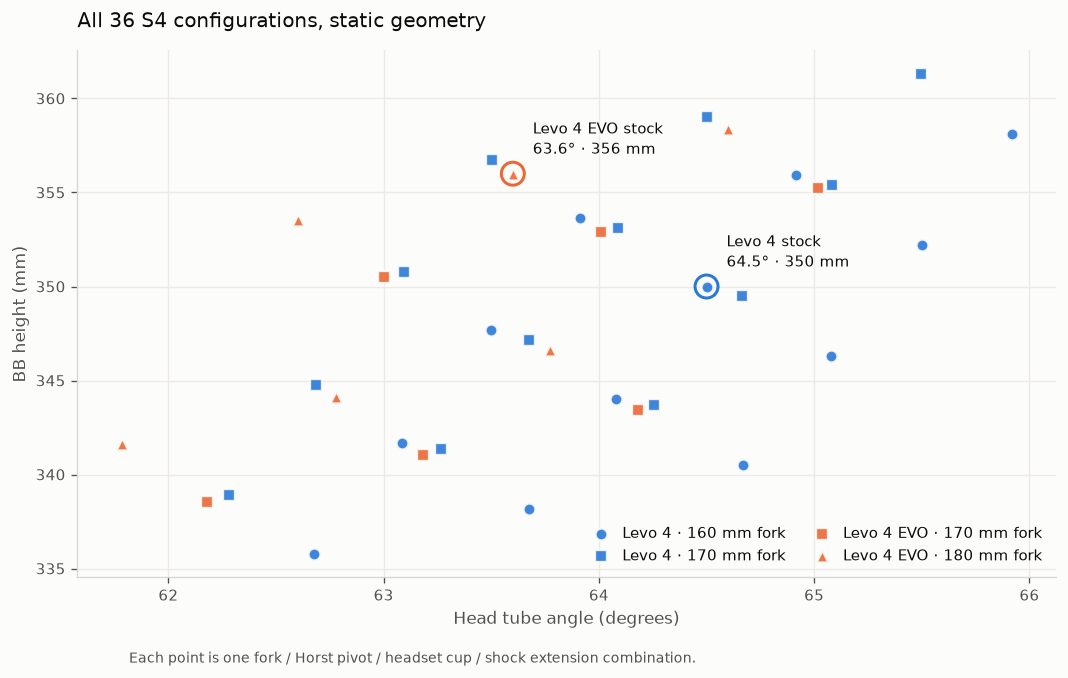

In [20]:
MARKERS = {160.0: "o", 170.0: "s", 180.0: "^"}

fig, ax = plt.subplots(figsize=(9, 5.6))
ax.set_axisbelow(True)
ax.grid(True, linewidth=0.8)

for model in MODELS:
    for travel in sorted(model.fork_travel_options):
        points = [r for r in STATIC[model.short] if r["fork_travel"] == travel]
        ax.scatter(
            [r["head_tube_angle"] for r in points],
            [r["bb_height"] for r in points],
            s=52,
            marker=MARKERS[travel],
            facecolor=SERIES[model.name],
            edgecolor=SURFACE,
            linewidth=1.4,
            alpha=0.9,
            label=f"{model.name} · {travel:.0f} mm fork",
            zorder=3,
        )

for model in MODELS:
    stock = next(r for r in STATIC[model.short] if r["is_stock"])
    ax.scatter(
        stock["head_tube_angle"], stock["bb_height"],
        s=190, facecolor="none", edgecolor=SERIES[model.name], linewidth=1.8, zorder=4,
    )
    ax.annotate(
        f"{model.name} stock\n{stock['head_tube_angle']:.1f}° · {stock['bb_height']:.0f} mm",
        (stock["head_tube_angle"], stock["bb_height"]),
        textcoords="offset points", xytext=(12, 12),
        fontsize=9, color=INK, linespacing=1.35, zorder=5,
    )

ax.set_xlabel("Head tube angle (degrees)")
ax.set_ylabel("BB height (mm)")
ax.set_title("All 36 S4 configurations, static geometry", loc="left", pad=14)
ax.legend(loc="lower right", ncol=2, handletextpad=0.4, columnspacing=1.4)
fig.text(
    0.125, 0.005,
    "Each point is one fork / Horst pivot / headset cup / shock extension combination.",
    fontsize=8.5, color=INK_SOFT,
)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

Two things to read off it. **The clouds overlap almost completely** — a Levo 4 on a 170 mm fork
with the Horst chip Long lands slacker *and* lower than a stock EVO, so the model badge is a much
weaker predictor of geometry than the setup. And **the cloud runs diagonally**, because every
adjustment except one moves head angle and BB height in the *same* direction: slackening also
means dropping. The exception is fork length — the squares sit up and to the left of the circles
of the same colour, so **a longer fork is the only way to slacken the head angle while raising the
BB**, rather than trading one against the other.

### What each adjustment actually moves

Levo 4, each adjustment applied on its own. **Filled bars are the three dimensions Specialized
publishes; hatched bars are the ones it does not.** Bars are signed — blue for an increase, red for
a decrease — and each panel has its own scale, so read the labels rather than comparing bar lengths
across panels.

findfont: Failed to find font weight medium, now using 400.


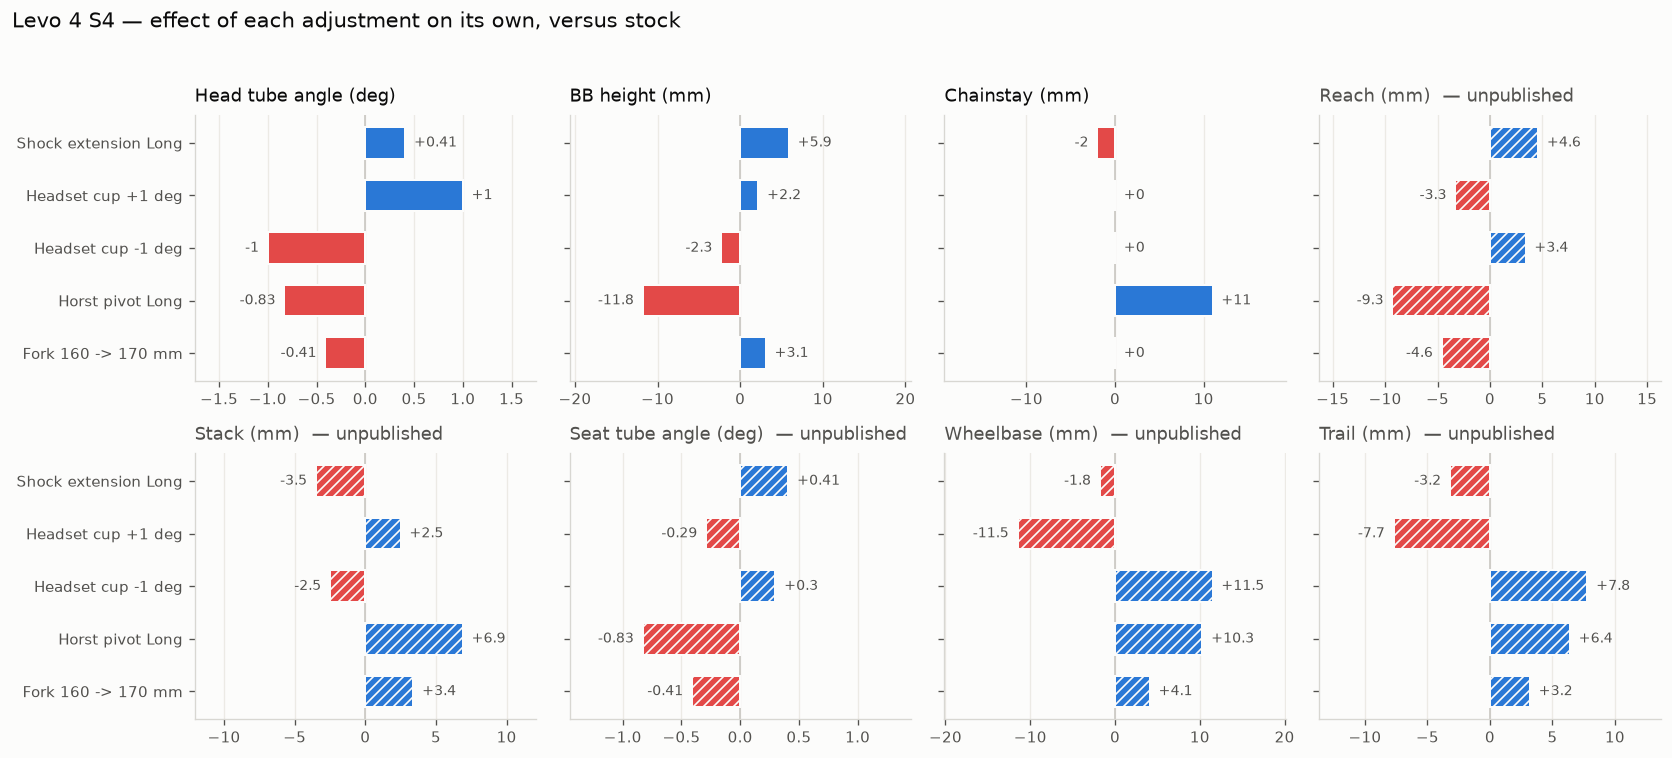

In [21]:
PANELS = [
    ("Head tube angle", "HTA", "deg", True),
    ("BB height", "BB height", "mm", True),
    ("Chainstay", "CS", "mm", True),
    ("Reach", "Reach †", "mm", False),
    ("Stack", "Stack †", "mm", False),
    ("Seat tube angle", "STA †", "deg", False),
    ("Wheelbase", "WB †", "mm", False),
    ("Trail", "Trail †", "mm", False),
]

deltas = ISOLATED["levo4"]
labels = list(deltas.index)
positions = range(len(labels))

fig, axes = plt.subplots(2, 4, figsize=(14, 6.4), sharey=True)
for ax, (title, column, unit, is_published) in zip(axes.ravel(), PANELS):
    values = deltas[column].tolist()
    ax.barh(
        list(positions), values, height=0.6,
        color=[POSITIVE if v >= 0 else NEGATIVE for v in values],
        hatch=None if is_published else "////",
        edgecolor=SURFACE, linewidth=1.2, zorder=3,
    )
    ax.axvline(0, color="#c9c7c1", linewidth=1, zorder=2)
    ax.set_axisbelow(True)
    ax.grid(True, axis="x", linewidth=0.8)
    ax.set_yticks(list(positions))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(f"{title} ({unit})", loc="left", fontsize=10.5, pad=8)
    if not is_published:
        ax.set_title(f"{title} ({unit})  — unpublished", loc="left", fontsize=10.5, pad=8,
                     color=INK_SOFT)
    span = max(abs(v) for v in values) or 1
    ax.set_xlim(-span * 1.75, span * 1.75)
    for pos, value in zip(positions, values):
        ax.text(
            value + span * 0.09 * (1 if value >= 0 else -1), pos,
            f"{value:+g}",
            va="center", ha="left" if value >= 0 else "right",
            fontsize=8.5, color=INK_SOFT, zorder=4,
        )

fig.suptitle(
    "Levo 4 S4 — effect of each adjustment on its own, versus stock",
    x=0.008, ha="left", fontsize=12.5, color=INK,
)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

The bottom row is the point of the whole exercise: the four dimensions Specialized never quotes
move as much as, or more than, the three it does. The Horst chip takes **9.3 mm out of reach** —
more than a stem size, and the biggest reach change on the chart. The headset cup swings
**wheelbase by ±11.5 mm**, more than any other adjustment including the ones sold as chainstay
adjustments, and moves **trail by ±8 mm**, which is where most of its change in steering feel
actually comes from. None of that is in the manual.

Note also that the two cups are not quite mirror images of each other — the bike re-levels from a
different attitude in each direction, so −1° buys 3.4 mm of reach while +1° gives back only 3.3 mm.

## 8. Export

In [22]:
from levo_geo.export import write_csvs

for path in write_csvs(ROOT / "output", fork_sag_fraction=FORK_SAG):
    print("wrote", path.relative_to(ROOT))

wrote output/levo4_s4_static.csv
wrote output/levo4_s4_sag.csv
wrote output/levo4_evo_s4_static.csv
wrote output/levo4_evo_s4_sag.csv


## 9. Assumptions and limitations

**Calibrated, not derived.** The Horst and shock-extension chips are fitted to the manual's three
published deltas. That fit is over-determined and closes to <0.2 mm, which is strong evidence the
model is right — but the chips' physical offsets are inferred, not measured.

**Headset cup convention.** The ±1.0° is anchored to the manual's head-angle column, which implies
a physically ≈1.3° cup and a BB change of ±2.2–2.4 mm against the manual's rounded ±2 mm. Modelling a
literal 1° cup instead would give a net ±0.77° head angle and ±1.8 mm of BB. The manual supports
both readings (§11.2 hedges with "approximately +/- 1 degree"); see §3.

**Rear wheel travel is held constant** at the published 150 mm / 170 mm for every configuration.
Specialized publishes no travel change for either flip chip, and the source data contains no
linkage pivot coordinates, so a per-configuration travel or leverage-progression figure cannot be
derived from it. The chips certainly change static ride height — that *is* modelled — and moving
the Horst pivot must perturb the leverage curve somewhat, but by how much is not knowable from this
data and is not guessed at here.

**Combining the two Levo 4 chips** assumes their rear-axle offsets add. Each is verified against
the manual on its own; the manual gives no combined figure to check the pair against.

**Standover (\*)** depends on top tube shape, which is not in the source data. It is modelled as a
fixed point on the seat tube at the published height; cross-checking that assumption between the
two charts disagrees by ~5 mm, so treat the standover column as indicative only. Every other
column is reconstructed from published frame dimensions.

**Chart rounding.** The published charts are internally inconsistent by up to ~1 mm (they are
over-determined and rounded). Anchoring absolutes to the published baseline keeps that slop out of
the deltas.

**The EVO chart says BB height 356 mm; the manual's §11.1 table says 355 mm.** The geometry chart is
used here.

**Fork sag of 15%** is an assumption — Specialized publishes a rear sag range but no fork figure.

**Every configuration listed is within Specialized's stated 160–180 mm fork range** for both
frames. Manual §11.1 warns that changing fork length or flip chip position alters BB height and
head angle "which can have negative effects on the bicycle's handling characteristics and ride
quality", and to consult a dealer before modifying.

## 10. Verification

`self_test()` re-checks every claim in this notebook: the flip-chip fits, the agreement between the
independently-fitted Levo 4 and EVO Horst offsets, the headset cup calibration, that both stock
rows reproduce the published charts exactly, that every single-adjustment row reproduces the
manual's delta table, the EVO rotation cross-check, the 24/12 configuration counts, and the
direction of every trend. It needs no Jupyter — `python3 -m levo_geo` runs it standalone.

In [23]:
from levo_geo import self_test

assert self_test(), "model self-test failed"

Flip-chip calibration (3 published targets, 2 free parameters):
  Levo 4      Horst Long       dx=-10.627 dy=+18.236  worst residual 0.1891
  Levo 4      Shock Ext Long   dx= +2.094 dy= -9.028  worst residual 0.0937
  Levo 4 EVO  Horst Long       dx=-10.627 dy=+18.224  worst residual 0.1483

Horst Long offset agreement between models: dx -10.627 vs -10.627, dy +18.236 vs +18.224

Headset cup calibration:
  Levo 4      -1 deg  physical tilt -1.302 deg  BB residual -0.29 mm
  Levo 4      0 deg   physical tilt +0.000 deg  BB residual +0.00 mm
  Levo 4      +1 deg  physical tilt +1.294 deg  BB residual +0.23 mm
  Levo 4 EVO  -1 deg  physical tilt -1.322 deg  BB residual -0.44 mm
  Levo 4 EVO  0 deg   physical tilt +0.000 deg  BB residual +0.00 mm
  Levo 4 EVO  +1 deg  physical tilt +1.313 deg  BB residual +0.38 mm

Stock row vs published chart:
  Levo 4      all 12 published columns match exactly
  Levo 4 EVO  all 12 published columns match exactly

Single-adjustment rows vs manual delta t